In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers
from tensorflow.keras.models import Model

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

X_train = train_df.drop(['Activity', 'subject'], axis=1)
X_test = test_df.drop(['Activity', 'subject'], axis=1)

y_train = train_df['Activity']
y_test = test_df['Activity']

# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Build Autoencoder Architecture

In [3]:
input_dim = X_train_scaled.shape[1]
input_layer = layers.Input(shape=(input_dim,))

# Encoder
encoded = layers.Dense(256, activation='relu')(input_layer)
encoded = layers.Dropout(0.1)(encoded)
encoded = layers.Dense(128, activation='relu')(encoded)
encoded = layers.Dropout(0.1)(encoded)
encoded = layers.Dense(64, activation='relu')(encoded)
# bottleneck
encoded = layers.Dense(32, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dropout(0.1)(decoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dropout(0.1)(decoded)
decoded = layers.Dense(256, activation='relu')(decoded)
# output layer
decoded = layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 561)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       143,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 561)            │       144,177 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 374,737 (1.43 MB)

 Trainable params: 374,737 (1.43 MB)

 Non-trainable params: 0 (0.00 B)

Train the Autoencoder

In [4]:
history = autoencoder.fit(X_train_scaled, X_train_scaled,
                          epochs=50,
                          batch_size=32,
                          validation_split=0.2, verbose=2)

Epoch 1/50
184/184 - 5s - 30ms/step - loss: 0.5290 - val_loss: 0.3381
Epoch 2/50
184/184 - 1s - 6ms/step - loss: 0.4064 - val_loss: 0.3016
Epoch 3/50
184/184 - 1s - 6ms/step - loss: 0.3796 - val_loss: 0.2888
Epoch 4/50
184/184 - 1s - 6ms/step - loss: 0.3586 - val_loss: 0.2829
Epoch 5/50
184/184 - 1s - 6ms/step - loss: 0.3442 - val_loss: 0.2825
Epoch 6/50
184/184 - 1s - 7ms/step - loss: 0.3351 - val_loss: 0.2756
Epoch 7/50
184/184 - 1s - 6ms/step - loss: 0.3317 - val_loss: 0.2728
Epoch 8/50
184/184 - 2s - 9ms/step - loss: 0.3239 - val_loss: 0.2726
Epoch 9/50
184/184 - 1s - 6ms/step - loss: 0.3194 - val_loss: 0.2692
Epoch 10/50
184/184 - 1s - 8ms/step - loss: 0.3161 - val_loss: 0.2721
Epoch 11/50
184/184 - 2s - 10ms/step - loss: 0.3116 - val_loss: 0.2675
Epoch 12/50
184/184 - 1s - 5ms/step - loss: 0.3085 - val_loss: 0.2693
Epoch 13/50
184/184 - 1s - 7ms/step - loss: 0.3032 - val_loss: 0.2637
Epoch 14/50
184/184 - 1s - 6ms/step - loss: 0.2988 - val_loss: 0.2712
Epoch 15/50
184/184 - 1s - 

Training Curves

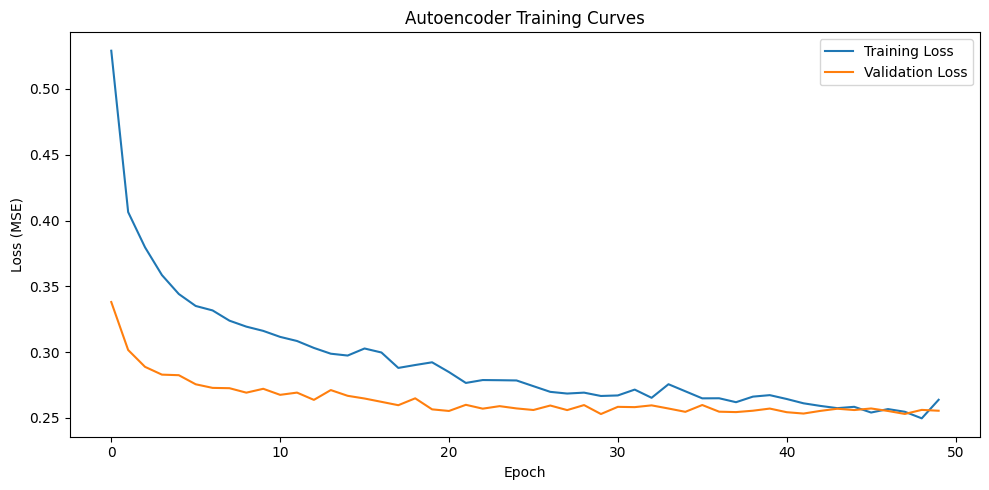

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()

Reconstruction Visualization

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


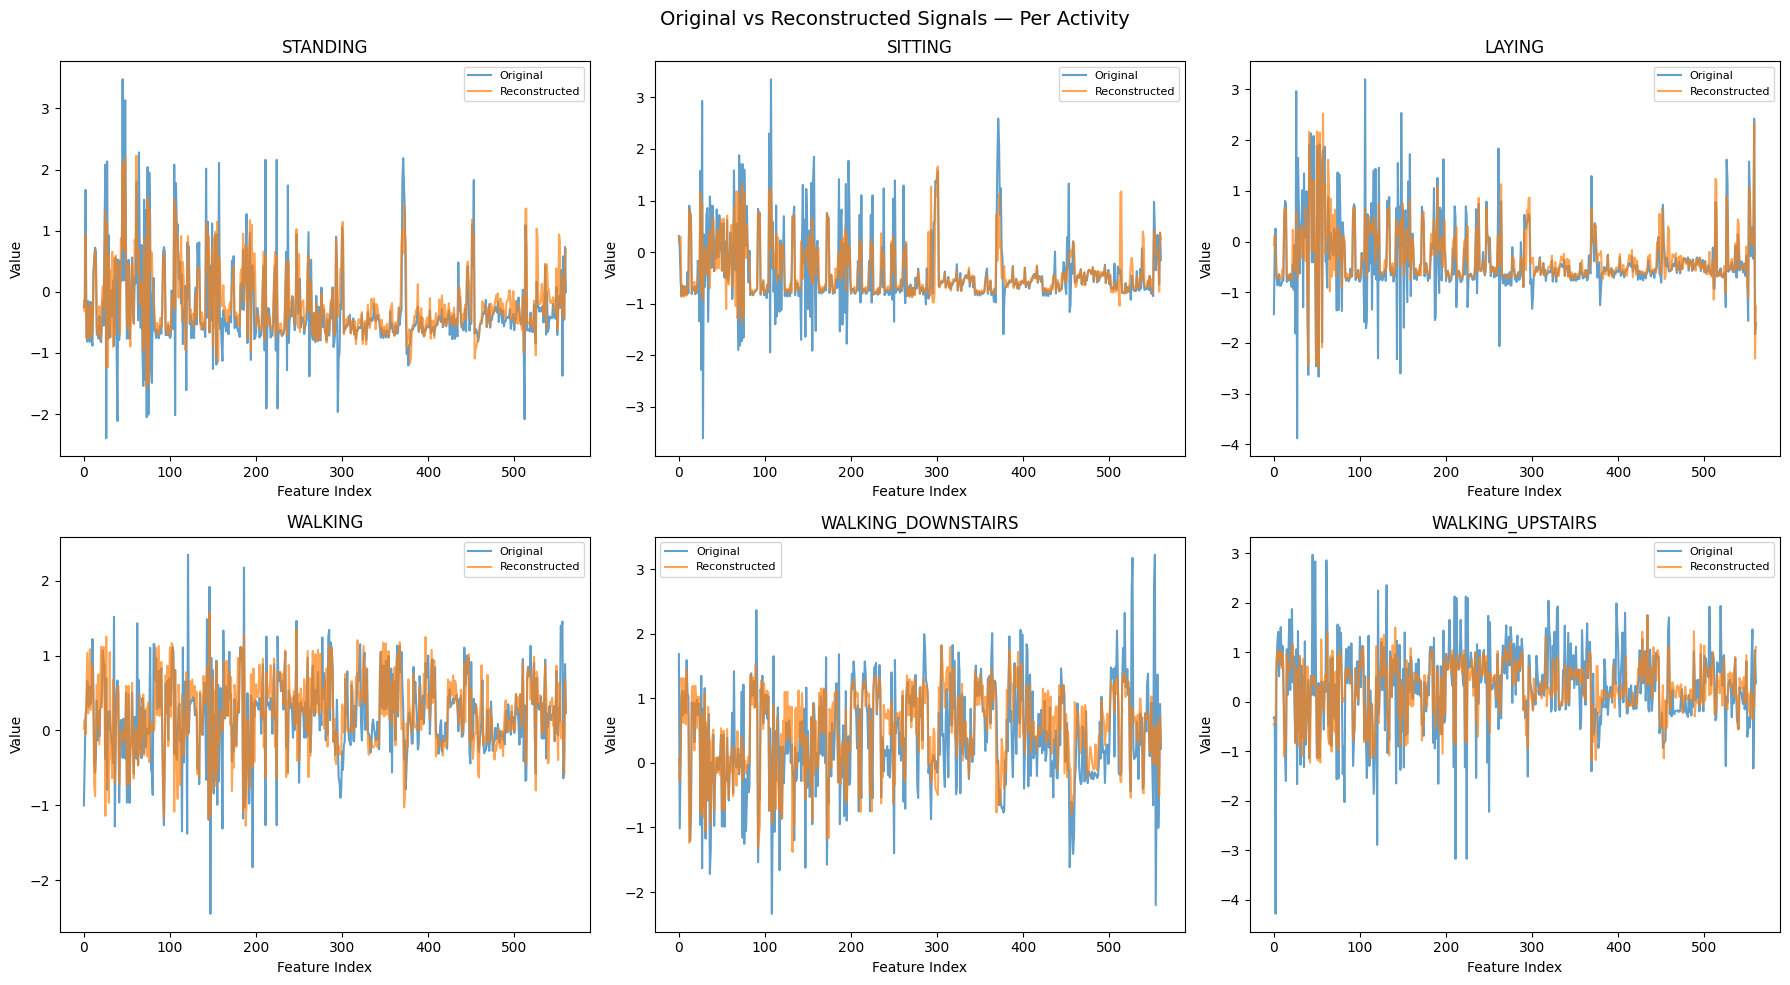

In [6]:
X_reconstructed = autoencoder.predict(X_test_scaled)

test_df_reset   = test_df.reset_index(drop=True)
activities      = test_df_reset['Activity'].unique()
sample_indices  = [test_df_reset[test_df_reset['Activity'] == act].index[0] for act in activities]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (idx, activity) in enumerate(zip(sample_indices, activities)):
    axes[i].plot(X_test_scaled[idx],label='Original', alpha=0.7)
    axes[i].plot(X_reconstructed[idx], label='Reconstructed',alpha=0.7)
    axes[i].set_title(activity)
    axes[i].set_xlabel('Feature Index')
    axes[i].set_ylabel('Value')
    axes[i].legend(fontsize=8)

plt.suptitle('Original vs Reconstructed Signals — Per Activity', fontsize=14)
plt.tight_layout()
plt.show()

Anomaly Detection

Threshold: 0.7105
Total anomalies found: 107

Anomalies per activity:
Activity
LAYING                 2
SITTING                1
STANDING               0
WALKING               29
WALKING_DOWNSTAIRS    64
WALKING_UPSTAIRS      11
Name: is_anomaly, dtype: int64


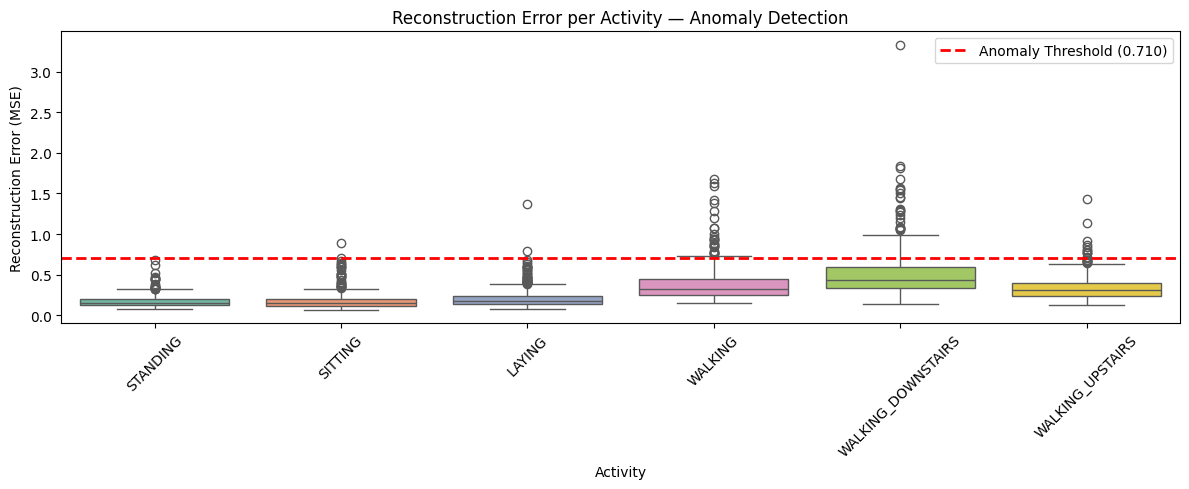

In [7]:
import seaborn as sns

# calculate reconstruction error per sample
reconstruction_errors = np.mean(
    np.power(X_test_scaled - X_reconstructed, 2),
    axis=1
)
test_df_reset['reconstruction_error'] = reconstruction_errors

# set threshold and flag anomalies
threshold = reconstruction_errors.mean() + 2 * reconstruction_errors.std()
test_df_reset['is_anomaly'] = reconstruction_errors > threshold

print(f"Threshold: {threshold:.4f}")
print(f"Total anomalies found: {test_df_reset['is_anomaly'].sum()}")
print(f"\nAnomalies per activity:")
print(test_df_reset.groupby('Activity')['is_anomaly'].sum())

plt.figure(figsize=(12, 5))
sns.boxplot(data=test_df_reset,
            x='Activity',
            y='reconstruction_error',
            hue='Activity',
            palette='Set2',
            legend=False)

plt.axhline(y=threshold,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Anomaly Threshold ({threshold:.3f})')

plt.title('Reconstruction Error per Activity — Anomaly Detection')
plt.xlabel('Activity')
plt.ylabel('Reconstruction Error (MSE)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()